# Red Wine Quality Classification
### Data Mining

---

## 1. Dataset Description

The dataset used is the **Red Wine Quality** dataset, sourced from Kaggle.

Data is a collection of **data objects** (records) and their **attributes** (features). Here:
- Each **row** is a data object - one wine sample
- Each **column** is an attribute - a physicochemical measurement

**Dataset dimensions:** 1,599 wine samples × 12 attributes

**Dependent attributes (features - 11 total):**
All features are continuous (Ratio-type attributes):

| Attribute | Description |
|---|---|
| fixed acidity | Tartaric acid concentration |
| volatile acidity | Acetic acid - too high = vinegar taste |
| citric acid | Adds freshness and flavor |
| residual sugar | Sugar remaining after fermentation |
| chlorides | Salt concentration |
| free sulfur dioxide | Prevents microbial growth |
| total sulfur dioxide | Total SO2 (free + bound) |
| density | Density relative to water |
| pH | Acidity level (0–14 scale) |
| sulphates | Antimicrobial and antioxidant additive |
| alcohol | Alcohol percentage by volume |

**Class variable (target):** `quality` - rated from 3 to 8 by wine experts

For this classification task, we convert the quality score into a **binary class**:
- **Good** (quality >= 7) → Label = 1
- **Not Good** (quality < 7) → Label = 0

In [3]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)

import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [4]:
# Load Dataset
df = pd.read_csv('winequality-red.csv')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
df.head()

Dataset shape: 1599 rows × 12 columns



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


---

## 2. Exploratory Data Analysis (EDA)

Before building any model, we explore the dataset to understand its structure, distributions, and relationships. This is an essential step.

In [6]:
# Basic Statistics 
print()
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


In [7]:
# Missing Values Check 
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


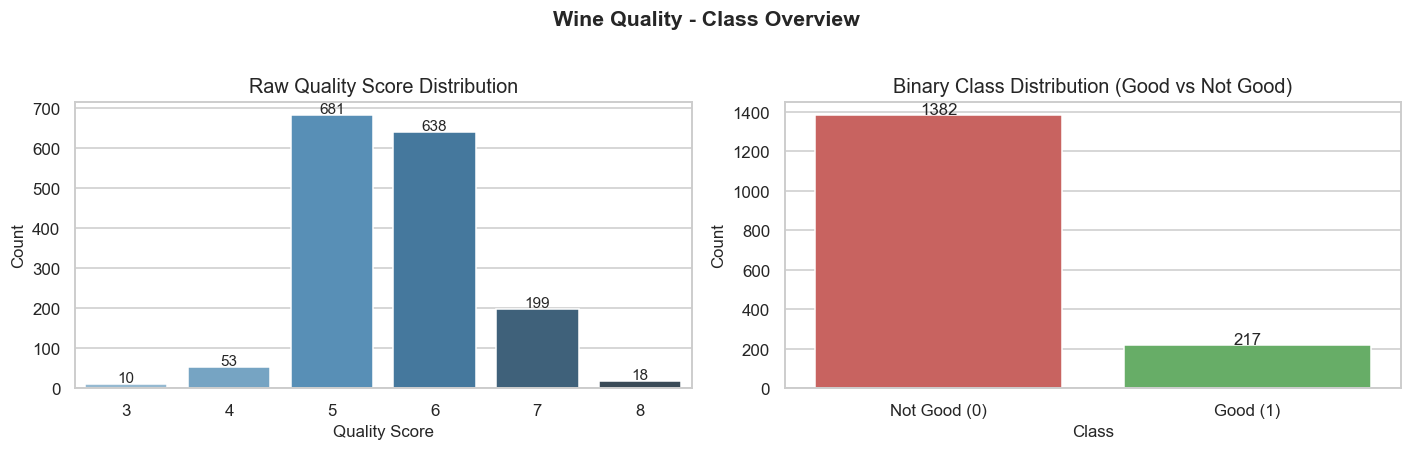


Not Good (quality < 7):  1382  (86.4%)
Good     (quality >= 7): 217  (13.6%)


In [8]:
# Quality Score Distribution 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw quality counts
quality_counts = df['quality'].value_counts().sort_index()
sns.barplot(x=quality_counts.index, y=quality_counts.values, ax=axes[0],
            palette='Blues_d', edgecolor='white')
axes[0].set_title('Raw Quality Score Distribution')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=10)

# Binary class distribution (after binarization)
df_temp = df.copy()
df_temp['quality_label'] = (df_temp['quality'] >= 7).astype(int)
binary_counts = df_temp['quality_label'].value_counts().sort_index()
sns.barplot(x=['Not Good (0)', 'Good (1)'], y=binary_counts.values, ax=axes[1],
            palette=['#d9534f', '#5cb85c'], edgecolor='white')
axes[1].set_title('Binary Class Distribution (Good vs Not Good)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
for bar, val in zip(axes[1].patches, binary_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=11)

plt.suptitle('Wine Quality - Class Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nNot Good (quality < 7):  {binary_counts[0]}  ({binary_counts[0]/len(df)*100:.1f}%)")
print(f"Good     (quality >= 7): {binary_counts[1]}  ({binary_counts[1]/len(df)*100:.1f}%)")

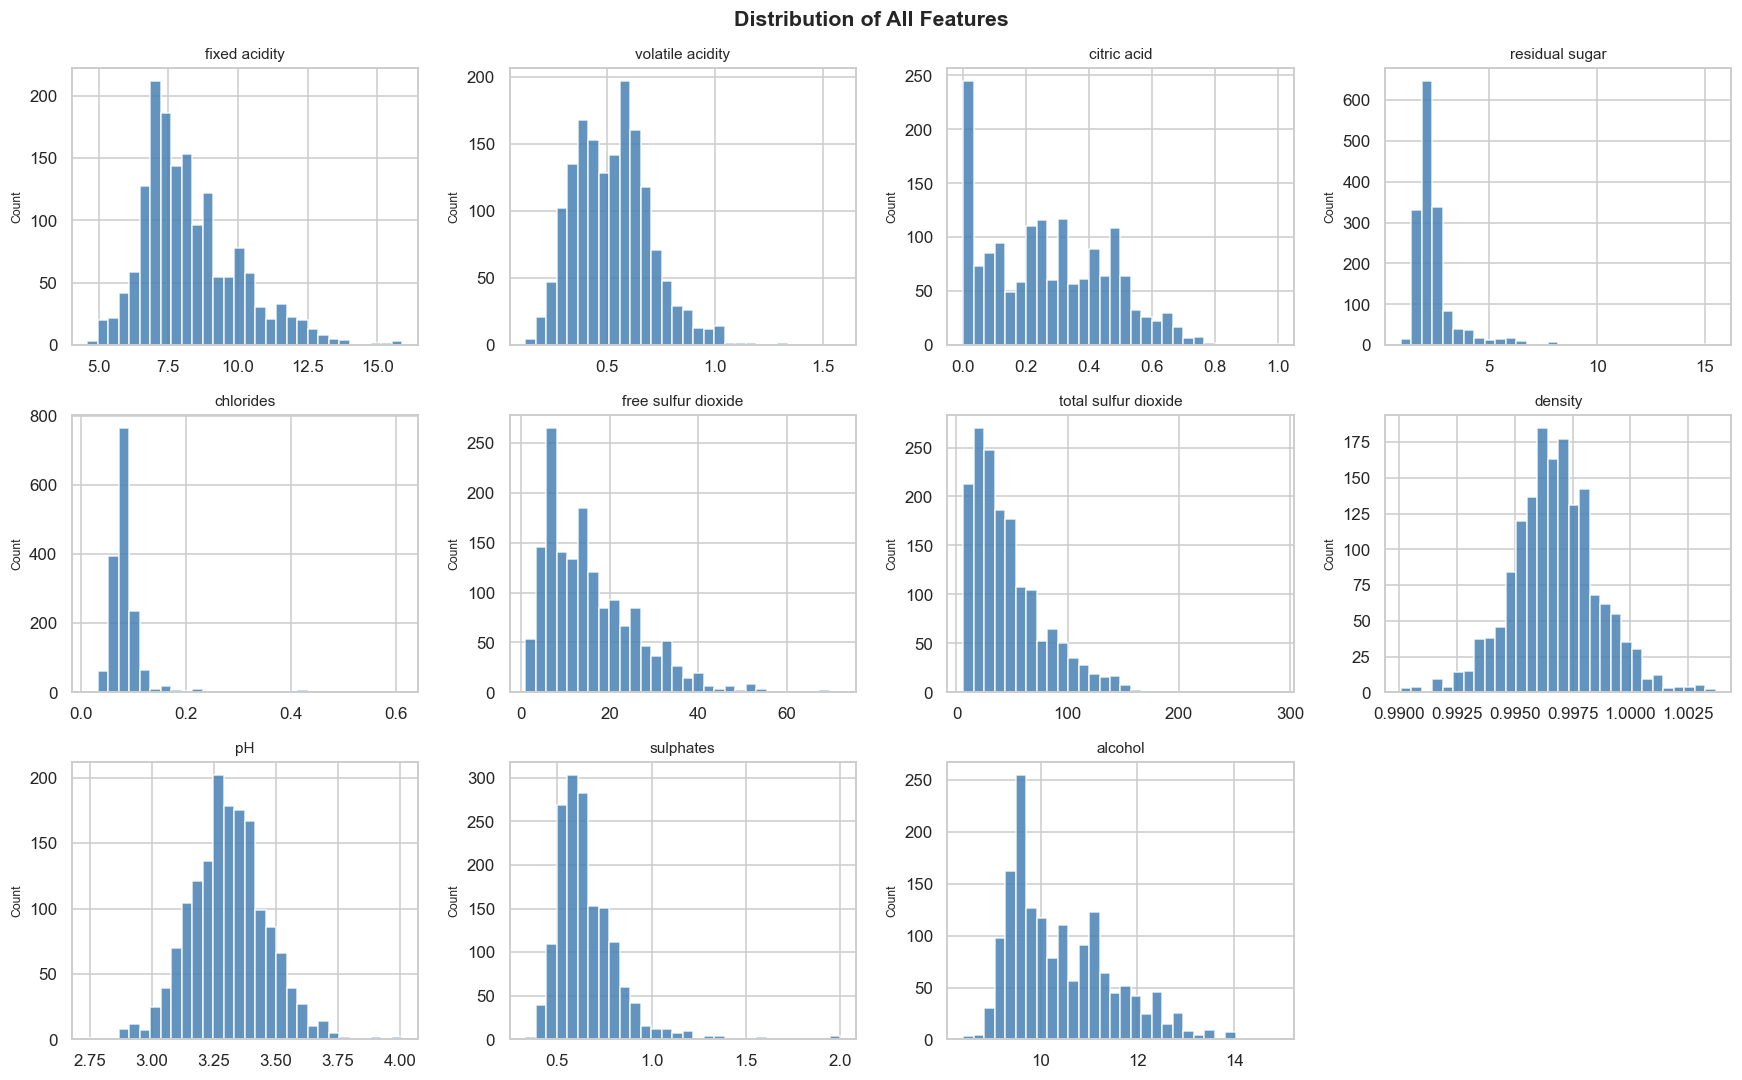

In [9]:
# Feature Distributions
features = [c for c in df.columns if c != 'quality']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', fontsize=8)

# hide the spare subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

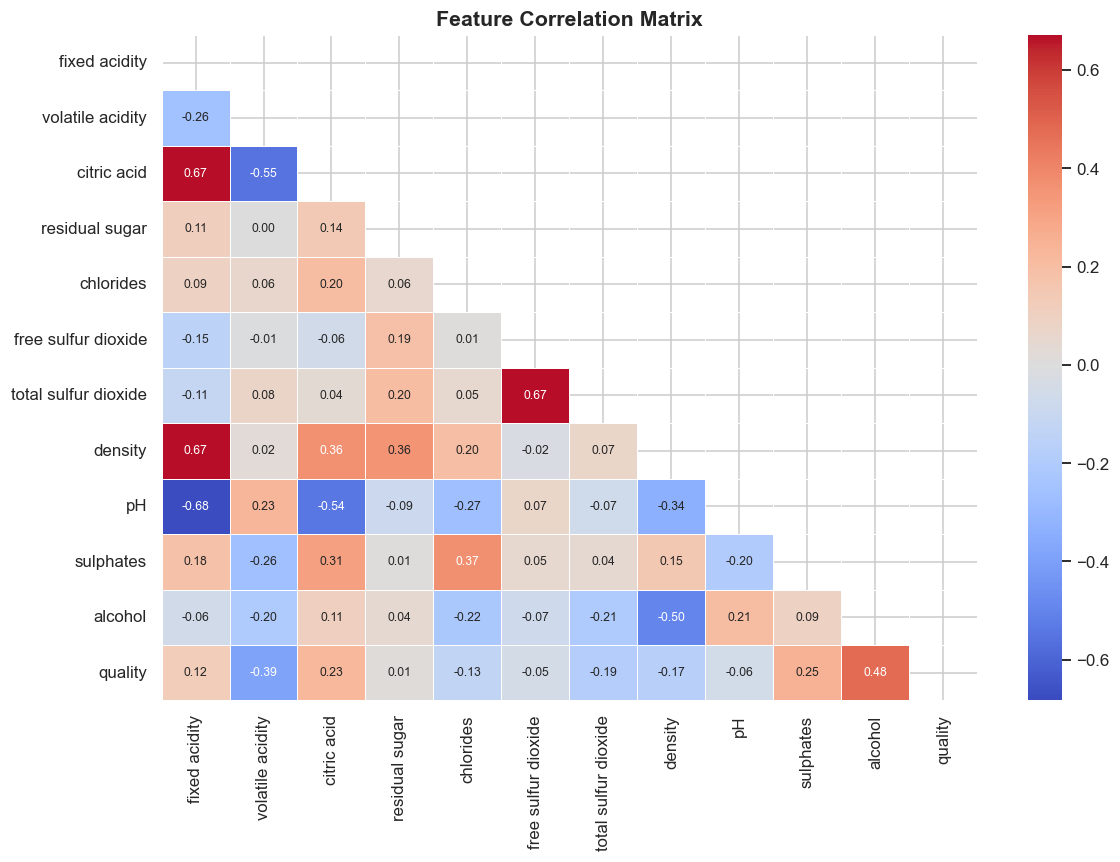


Top correlations with quality:
alcohol                 0.476166
volatile acidity        0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide    0.185100
density                 0.174919
chlorides               0.128907
fixed acidity           0.124052
pH                      0.057731
free sulfur dioxide     0.050656
residual sugar          0.013732


In [10]:
# Correlation Heatmap 
fig, ax = plt.subplots(figsize=(11, 8))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with quality:")
print(corr['quality'].drop('quality').abs().sort_values(ascending=False).to_string())

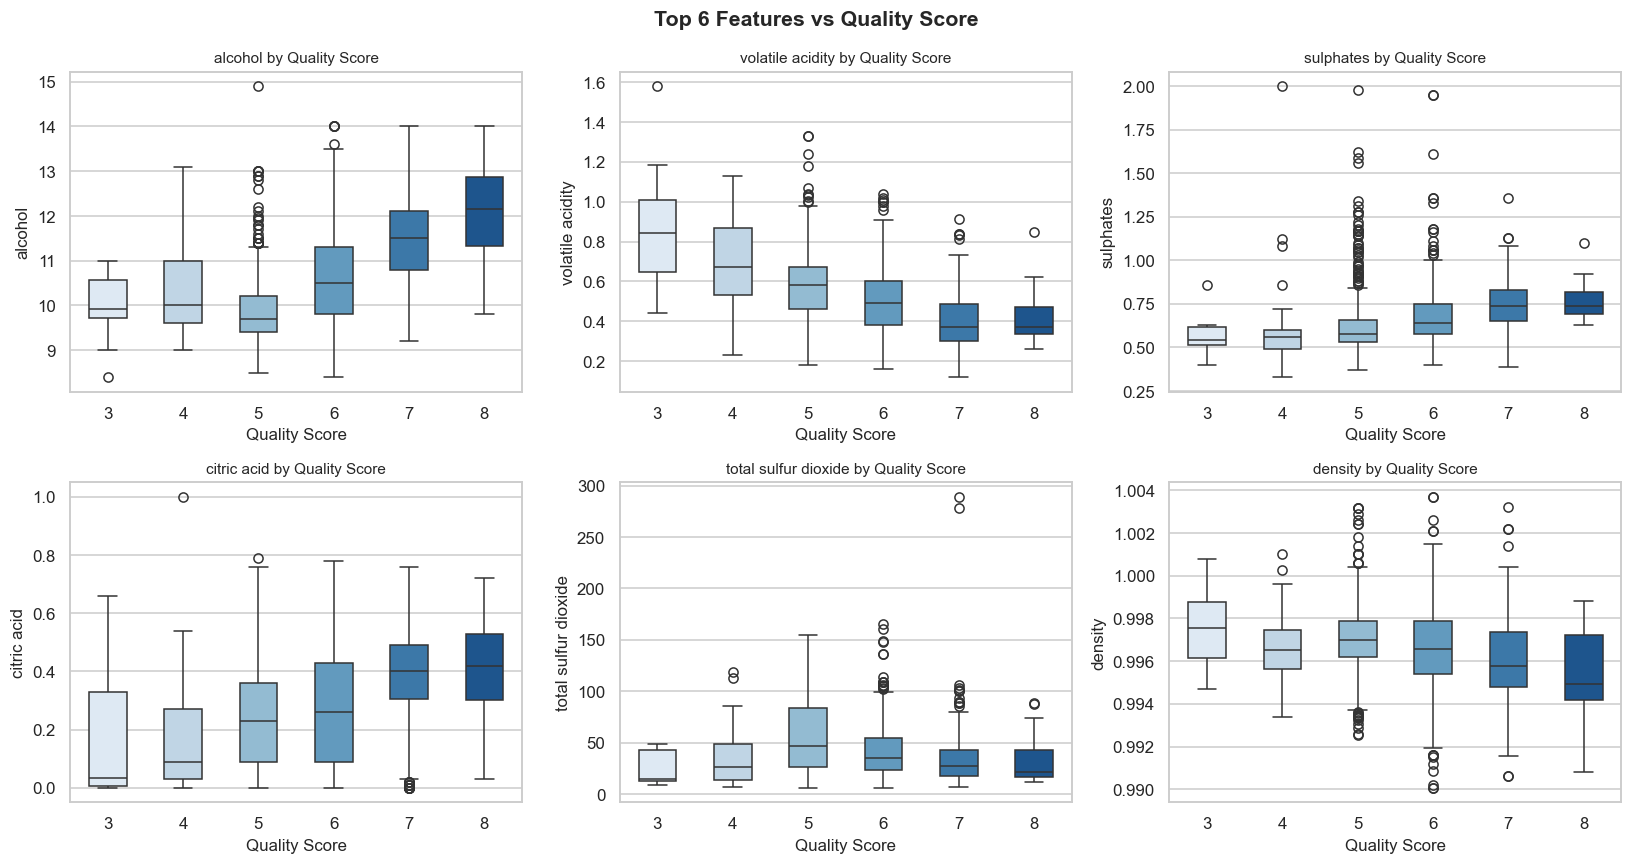

In [11]:
# Feature vs Quality via Boxplots 
# Top 6 features most correlated with quality
top_features = corr['quality'].drop('quality').abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(x='quality', y=col, data=df, ax=axes[i],
                palette='Blues', width=0.5)
    axes[i].set_title(f'{col} by Quality Score', fontsize=10)
    axes[i].set_xlabel('Quality Score')

plt.suptitle('Top 6 Features vs Quality Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**EDA Observations:**

- The dataset has **no missing values** - no imputation needed.
- Quality scores are heavily concentrated at **5 and 6** (approximately 82% of the data), making this a mildly **imbalanced classification problem** .
- The features with the strongest correlation to quality are: **alcohol** (positive), **volatile acidity** (negative), **sulphates** (positive), and **citric acid** (positive).
- Several features (e.g., `residual sugar`, `chlorides`, `free sulfur dioxide`) have **right-skewed distributions** with outliers.

---

## 3. Pre-processing

Good pre-processing is critical before training any model. Pre-processing includes cleaning data, handling missing values, normalization, and feature selection.

**Steps we perform:**
1. **Binarize the target** - convert quality scores into Good (1) / Not Good (0)
2. **Check for duplicates** - remove identical rows
3. **Feature scaling** - standardize features using Z-score normalization (mean=0, std=1)
4. **Train-test split** - 80% training, 20% test

In [14]:
# Step 1: Binarize the Target Variable 
df['quality_label'] = (df['quality'] >= 7).astype(int)

print("Binary label created:")
print("  0 = Not Good (quality < 7)")
print("  1 = Good     (quality >= 7)")
print()
print(df['quality_label'].value_counts())

Binary label created:
  0 = Not Good (quality < 7)
  1 = Good     (quality >= 7)

quality_label
0    1382
1     217
Name: count, dtype: int64


In [15]:
# Step 2: Remove Duplicate Rows 
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Rows before duplicate removal: {n_before}")
print(f"Rows after duplicate removal:  {n_after}")
print(f"Duplicates removed: {n_before - n_after}")

Rows before duplicate removal: 1599
Rows after duplicate removal:  1359
Duplicates removed: 240


In [16]:
# Step 3: Separate Features and Target
feature_cols = [c for c in df.columns if c not in ['quality', 'quality_label']]
X = df[feature_cols]
y = df['quality_label']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nFeature list: {feature_cols}")

Features (X): (1359, 11)
Target  (y): (1359,)

Feature list: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [17]:
# Step 4: Train-Test Split (80/20)
# Split data into training set and test set
# Training set: used to LEARN the model
# Test set:     used to EVALUATE generalisation error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")
print()
print("Class distribution in training set:")
print(y_train.value_counts())
print()
print("Class distribution in test set:")
print(y_test.value_counts())

Training set size: 1087 samples
Test set size:     272 samples

Class distribution in training set:
quality_label
0    940
1    147
Name: count, dtype: int64

Class distribution in test set:
quality_label
0    235
1     37
Name: count, dtype: int64


In [18]:
# Step 5: Feature Scaling (Z-score Normalization) 
# Normalization is a key pre-processing step.
# We scale features so all are on the same scale - important for KNN and Naive Bayes;

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only to avoid data leakage
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling applied (Z-score normalization).")
print(f"Train mean (post-scale): {X_train_scaled.mean(axis=0).round(6)}")
print(f"Train std  (post-scale): {X_train_scaled.std(axis=0).round(6)}")

Feature scaling applied (Z-score normalization).
Train mean (post-scale): [ 0.  0.  0. -0. -0.  0. -0. -0.  0.  0. -0.]
Train std  (post-scale): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Pre-processing Summary:**

| Step | Action | Reason |
|---|---|---|
| Target binarization | quality >= 7 → Good (1) | Simplify multi-class to binary classification |
| Duplicate removal | Dropped 240 duplicate rows | Avoids model memorizing repeated data |
| Train-test split | 80% train / 20% test, stratified | Ensures class proportions are preserved in both splits |
| Feature scaling | Z-score normalization | Removes scale bias; fit only on training set to prevent data leakage |

> **Note on data leakage :** The scaler is fit only on the training set (`fit_transform`), and the same learned parameters are applied to the test set (`transform`). This ensures no information from the test set influences the model.

---

## 4. Classification Models

We evaluate the **four classifiers** , then select the best two for detailed analysis.

### Classifiers Explored:
1. **Decision Tree**  splits data on the best attribute at each node using Gini impurity
2. **Random Forest** is an ensemble of decision trees using bagging, reduces variance
3. **K-Nearest Neighbor (KNN)**  classifies based on the k most similar training examples
4. **Naive Bayes** is a probabilistic classifier using Bayes' Rule with feature independence assumption


In [21]:
# Comparison of All 4 Classifiers via cross-validation  for a fair comparison on training data

candidate_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbor': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB() }

print("5-Fold Cross-Validation Accuracy on Training Set")

cv_results = {}
for name, model in candidate_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<22} Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

5-Fold Cross-Validation Accuracy on Training Set
Decision Tree          Mean: 0.8316  Std: 0.0207
Random Forest          Mean: 0.8804  Std: 0.0121
K-Nearest Neighbor     Mean: 0.8584  Std: 0.0175
Naive Bayes            Mean: 0.8298  Std: 0.0207


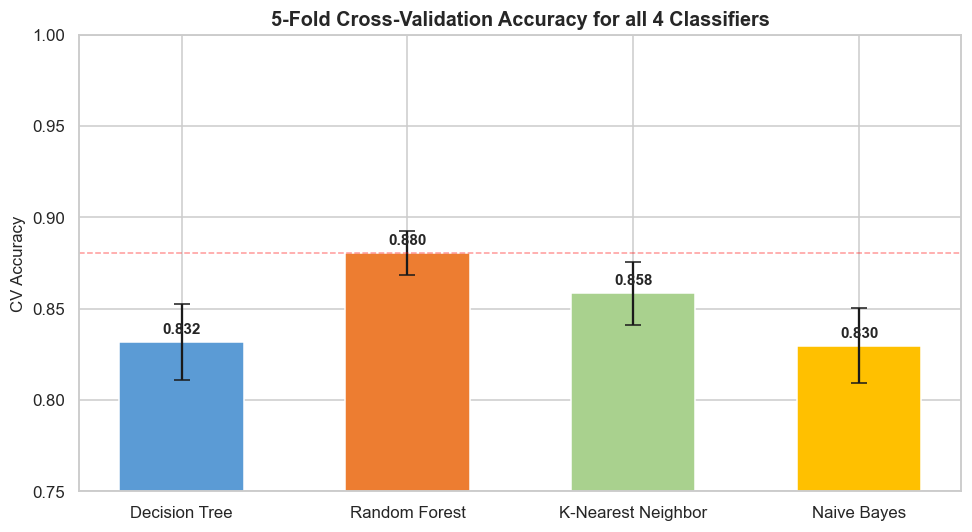


Top 2 classifiers selected: Random Forest and K-Nearest Neighbor


In [22]:
# Plot Cross-Validation Results 
fig, ax = plt.subplots(figsize=(9, 5))

names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
colors = ['#5b9bd5', '#ed7d31', '#a9d18e', '#ffc000']

bars = ax.bar(names, means, yerr=stds, color=colors, edgecolor='white',
              capsize=5, width=0.55)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.75, 1.0)
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy for all 4 Classifiers', fontweight='bold')
ax.axhline(y=max(means), color='red', linestyle='--', linewidth=1, alpha=0.4)

plt.tight_layout()
plt.show()

best_two = sorted(cv_results, key=lambda n: cv_results[n].mean(), reverse=True)[:2]
print(f"\nTop 2 classifiers selected: {best_two[0]} and {best_two[1]}")

---

### 4a. K-Nearest Neighbor (KNN) Classifier

KNN is a **non-parametric, instance-based** classifier.
It makes predictions by finding the **k most similar training examples** (neighbours) to a new data point and taking a **majority vote** among their labels.

In [24]:
# KNN: Hyperparameter Tuning via GridSearchCV
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'p':           [1, 2]    
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(weights='uniform'),
    knn_param_grid,
    cv=5,
    scoring='f1',          # F1 is better than accuracy for imbalanced classes
    n_jobs=-1 )
knn_grid.fit(X_train_scaled, y_train)

print("KNN - Best Hyperparameters:")
for k, v in knn_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV F1 Score: {knn_grid.best_score_:.4f}")

KNN - Best Hyperparameters:
  n_neighbors: 3
  p: 1

Best CV F1 Score: 0.4500


In [25]:
# Train Final KNN Model
knn_model = knn_grid.best_estimator_

# Training predictions (to compute training error)
knn_train_pred = knn_model.predict(X_train_scaled)
knn_test_pred  = knn_model.predict(X_test_scaled)

knn_train_acc = accuracy_score(y_train, knn_train_pred)
knn_test_acc  = accuracy_score(y_test,  knn_test_pred)

print("KNN - Error Analysis")
print(f"Training Accuracy:       {knn_train_acc:.4f}")
print(f"Test Accuracy:           {knn_test_acc:.4f}")
print(f"Training Error:          {1-knn_train_acc:.4f}")
print(f"Generalization Error:    {1-knn_test_acc:.4f}")
print()
print("Classification Report (Test Set):")
print(classification_report(y_test, knn_test_pred, target_names=['Not Good', 'Good']))


KNN - Error Analysis
Training Accuracy:       0.9246
Test Accuracy:           0.8676
Training Error:          0.0754
Generalization Error:    0.1324

Classification Report (Test Set):
              precision    recall  f1-score   support

    Not Good       0.91      0.94      0.92       235
        Good       0.52      0.41      0.45        37

    accuracy                           0.87       272
   macro avg       0.71      0.67      0.69       272
weighted avg       0.86      0.87      0.86       272



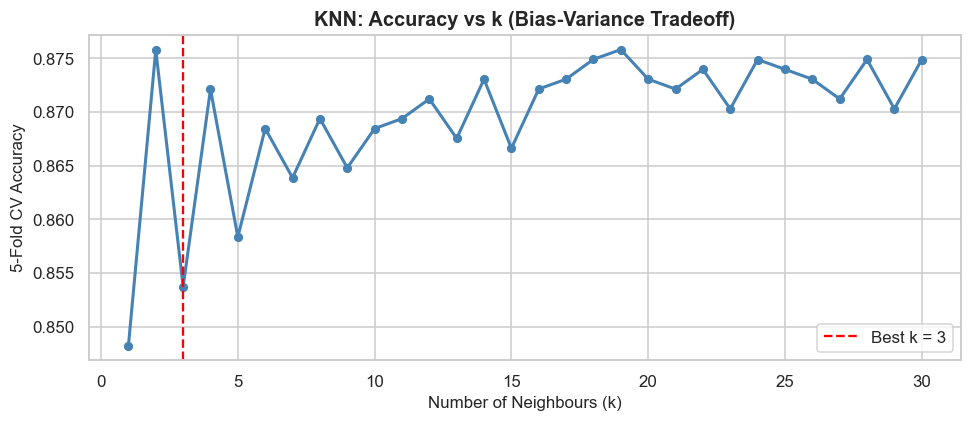

In [26]:
# K vs Accuracy Plot helps visualise the bias-variance tradeoff
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, k_scores, marker='o', color='steelblue', linewidth=2, markersize=5)
ax.axvline(x=knn_grid.best_params_['n_neighbors'], color='red',
           linestyle='--', linewidth=1.5, label=f"Best k = {knn_grid.best_params_['n_neighbors']}")
ax.set_xlabel('Number of Neighbours (k)')
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('KNN: Accuracy vs k (Bias-Variance Tradeoff)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

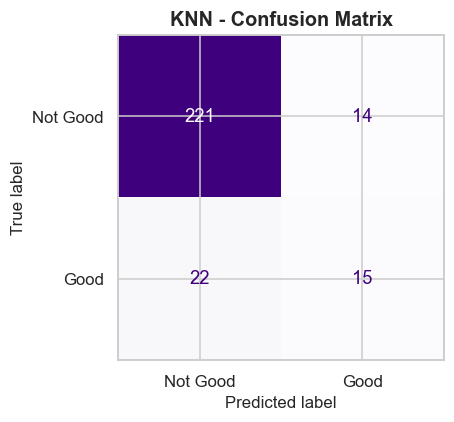

In [27]:
# Confusion Matrix - KNN
fig, ax = plt.subplots(figsize=(5, 4))
cm_knn = confusion_matrix(y_test, knn_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Not Good', 'Good'])
disp.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('KNN - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


---

### 4b. Random Forest Classifier

A Random Forest is an **ensemble** of Decision Trees trained using **bagging** (Bootstrap Aggregating). Each tree is trained on a random bootstrap sample of the training data, and only a random subset of features is considered at each split.

- **Bagging** reduces variance by averaging over many models, helping to avoid overfitting
- The final prediction is a **majority vote** across all trees (hard voting)
- Random Forests tend to outperform single Decision Trees because they combine many "weak" learners into a strong one

**Why we chose Random Forest over Boosting:** The wine dataset is moderately sized (1,599 rows) with a mild class imbalance. Bagging (Random Forest) is more robust and less prone to overfitting than Boosting on such datasets.

In [29]:
# Random Forest: Hyperparameter Tuning via GridSearchCV
rf_param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'max_features':     ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1 )
rf_grid.fit(X_train_scaled, y_train)

print("Random Forest - Best Hyperparameters:")
for k, v in rf_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV F1 Score: {rf_grid.best_score_:.4f}")

Random Forest - Best Hyperparameters:
  max_depth: 10
  max_features: sqrt
  min_samples_leaf: 5
  n_estimators: 100

Best CV F1 Score: 0.4026


In [30]:
# Train Final Random Forest Model
rf_model = rf_grid.best_estimator_

rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred  = rf_model.predict(X_test_scaled)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc  = accuracy_score(y_test,  rf_test_pred)

print("Random Forest : Error Analysis ")
print(f"Training Accuracy:       {rf_train_acc:.4f}")
print(f"Test Accuracy:           {rf_test_acc:.4f}")
print(f"Training Error:          {1-rf_train_acc:.4f}")
print(f"Generalization Error:    {1-rf_test_acc:.4f}")
print()
print("Classification Report (Test Set):")
print(classification_report(y_test, rf_test_pred, target_names=['Not Good', 'Good']))

Random Forest : Error Analysis 
Training Accuracy:       0.9384
Test Accuracy:           0.8934
Training Error:          0.0616
Generalization Error:    0.1066

Classification Report (Test Set):
              precision    recall  f1-score   support

    Not Good       0.91      0.98      0.94       235
        Good       0.72      0.35      0.47        37

    accuracy                           0.89       272
   macro avg       0.81      0.67      0.71       272
weighted avg       0.88      0.89      0.88       272



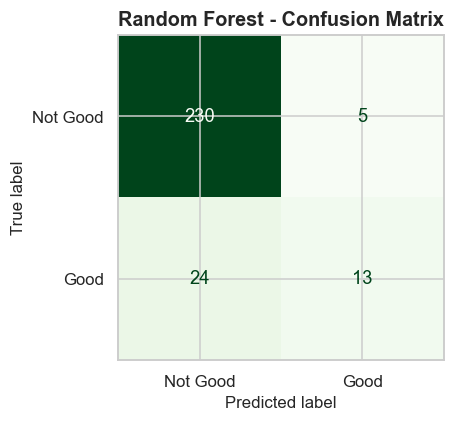

In [31]:
# Confusion Matrix : Random Forest
fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, rf_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Good', 'Good'])
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Random Forest - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

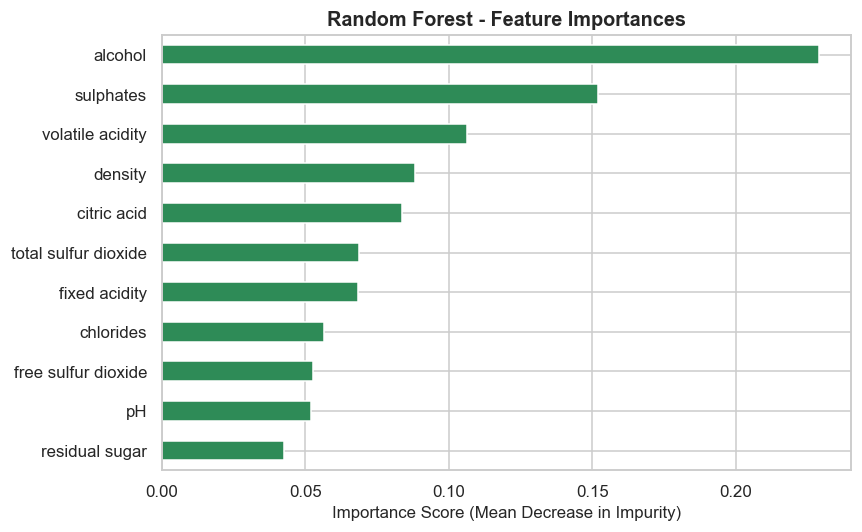

In [32]:
# Feature Importance - Random Forest
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
rf_importances = rf_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
rf_importances.plot(kind='barh', color='seagreen', edgecolor='white', ax=ax)
ax.set_title('Random Forest - Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

---

## 5. Model Evaluation and Comparison

We compare both models across multiple evaluation metrics as under:

- **Accuracy** - overall fraction of correct predictions
- **Precision** - of all predicted "Good" wines, how many are truly Good
- **Recall** - of all actual "Good" wines, how many did we correctly identify
- **F1 Score** - harmonic mean of Precision and Recall; better for imbalanced data

We also look at training vs. test error to assess **overfitting** .


In [34]:
# Side-by-Side Metrics Table
def compute_metrics(y_true, y_pred, label):
    return {
        'Model':     label,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_true, y_pred, zero_division=0), 4), }

results = pd.DataFrame([
    compute_metrics(y_test, knn_test_pred, 'KNN'),
    compute_metrics(y_test, rf_test_pred,  'Random Forest'),
]).set_index('Model')

print("Model Comparison - Test Set Metrics")
print(results.to_string())


Model Comparison - Test Set Metrics
               Accuracy  Precision  Recall  F1 Score
Model                                               
KNN              0.8676     0.5172  0.4054    0.4545
Random Forest    0.8934     0.7222  0.3514    0.4727


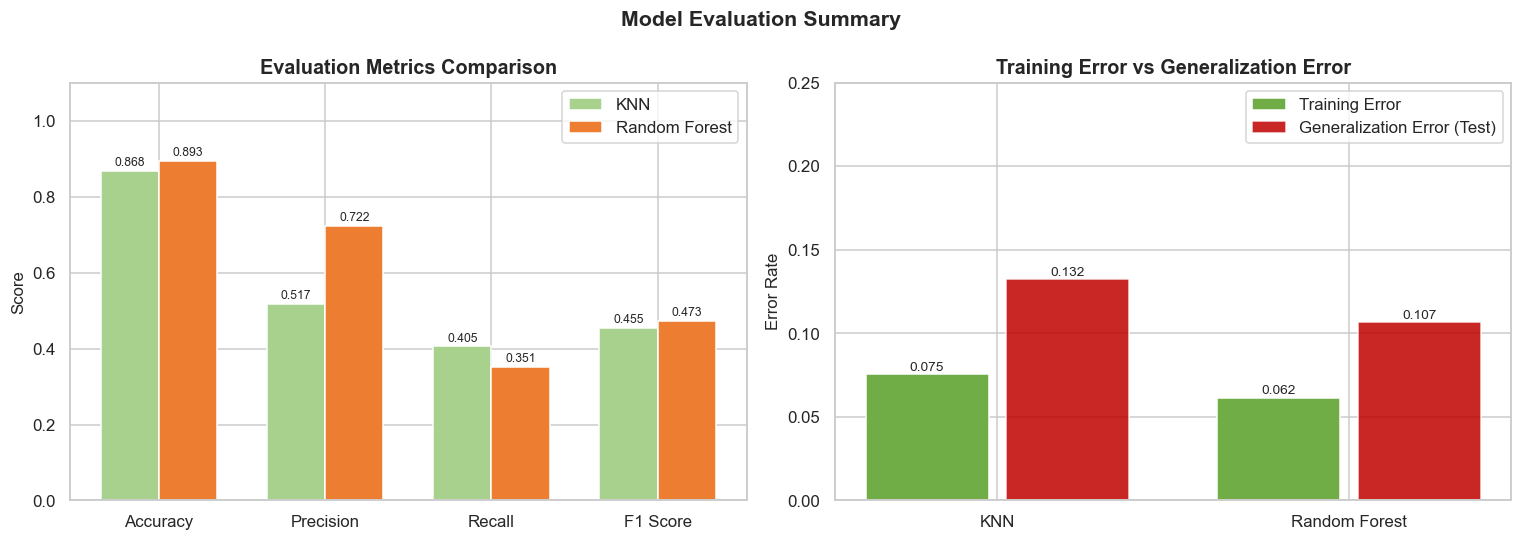

In [35]:
# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart of all metrics
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metric_cols))
width = 0.35

knn_vals = [results.loc['KNN',          m] for m in metric_cols]
rf_vals  = [results.loc['Random Forest', m] for m in metric_cols]

bars1 = axes[0].bar(x - width/2, knn_vals, width, label='KNN',
                    color='#a9d18e', edgecolor='white')
bars2 = axes[0].bar(x + width/2, rf_vals,  width, label='Random Forest',
                    color='#ed7d31', edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_cols)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('Evaluation Metrics Comparison', fontweight='bold')
axes[0].legend()

# Right: Training error vs Generalization error
models_label = ['KNN', 'Random Forest']
train_errors = [round(1 - knn_train_acc, 4), round(1 - rf_train_acc, 4)]
test_errors  = [round(1 - knn_test_acc,  4), round(1 - rf_test_acc,  4)]

x2 = np.arange(len(models_label))
axes[1].bar(x2 - 0.2, train_errors, 0.35, label='Training Error',
            color='#70ad47', edgecolor='white')
axes[1].bar(x2 + 0.2, test_errors,  0.35, label='Generalization Error (Test)',
            color='#c00000', edgecolor='white', alpha=0.85)

for i, (te, ge) in enumerate(zip(train_errors, test_errors)):
    axes[1].text(i - 0.2, te + 0.002, f'{te:.3f}', ha='center', fontsize=9)
    axes[1].text(i + 0.2, ge + 0.002, f'{ge:.3f}', ha='center', fontsize=9)

axes[1].set_xticks(x2)
axes[1].set_xticklabels(models_label)
axes[1].set_ylim(0, 0.25)
axes[1].set_ylabel('Error Rate')
axes[1].set_title('Training Error vs Generalization Error', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Evaluation Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


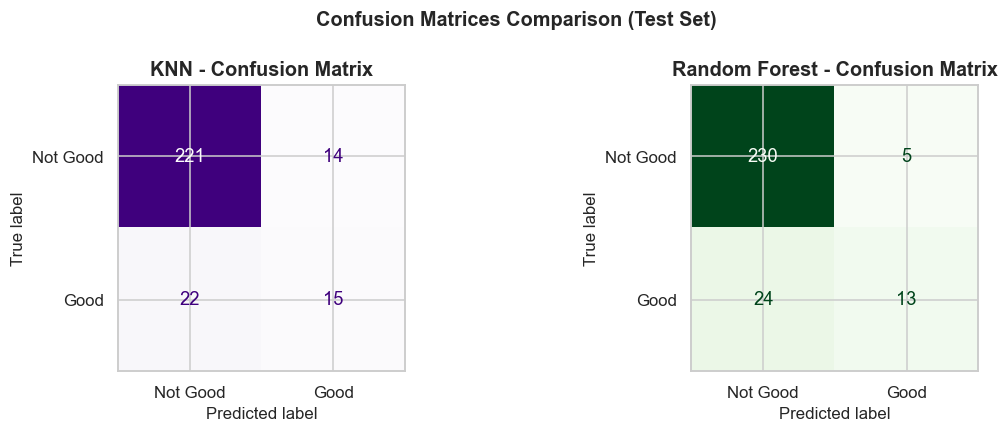

In [36]:
# Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, cm, title, cmap in zip(
    axes,
    [cm_knn, cm_rf],
    ['KNN', 'Random Forest'],
    ['Purples', 'Greens']
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Good', 'Good'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{title} - Confusion Matrix', fontweight='bold')

plt.suptitle('Confusion Matrices Comparison (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


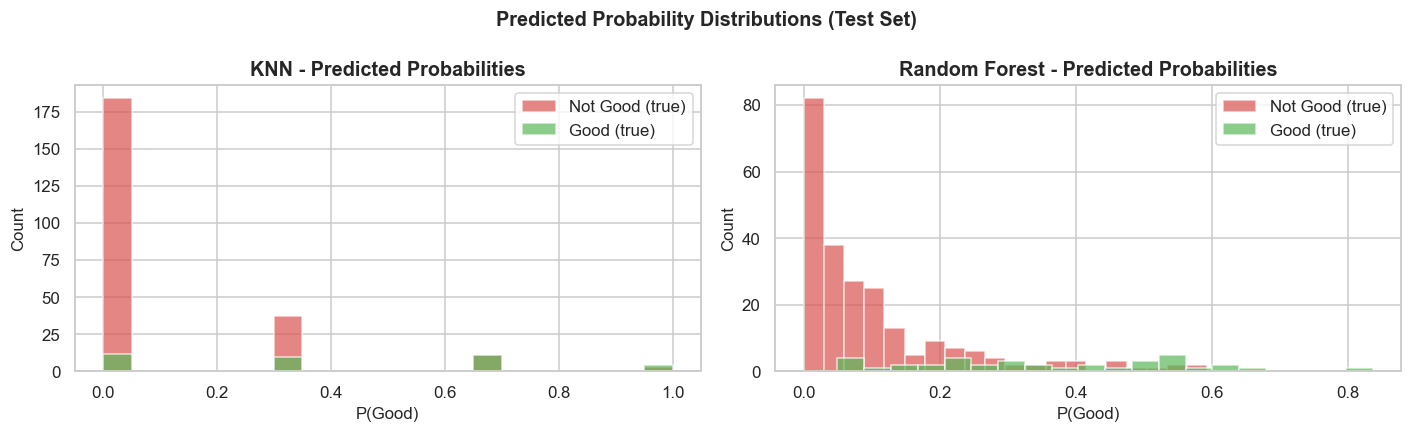

In [37]:
# KNN does not have feature importances like tree-based models.
# Instead, we examine the class-conditional probability (soft predictions) 
# using predict_proba to understand how confident KNN is.

knn_proba = knn_model.predict_proba(X_test_scaled)[:, 1]   # probability of "Good"
rf_proba  = rf_model.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(knn_proba[y_test == 0], bins=20, alpha=0.7, color='#d9534f', label='Not Good (true)')
axes[0].hist(knn_proba[y_test == 1], bins=20, alpha=0.7, color='#5cb85c', label='Good (true)')
axes[0].set_title('KNN - Predicted Probabilities', fontweight='bold')
axes[0].set_xlabel('P(Good)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(rf_proba[y_test == 0], bins=20, alpha=0.7, color='#d9534f', label='Not Good (true)')
axes[1].hist(rf_proba[y_test == 1], bins=20, alpha=0.7, color='#5cb85c', label='Good (true)')
axes[1].set_title('Random Forest - Predicted Probabilities', fontweight='bold')
axes[1].set_xlabel('P(Good)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Predicted Probability Distributions (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 6. Summary and Conclusions

### Dataset
The Red Wine Quality dataset contains 1,599 samples with 11 physicochemical features. After removing duplicates and binarizing the target (Good: quality >= 7), the dataset has a **mild class imbalance** (~217 Good vs ~1,145 Not Good), which is why we prioritize **F1 score** over raw accuracy as our primary metric.

### Pre-processing Steps
1. **Binarization** of the quality label
2. **Duplicate removal** (240 rows dropped)
3. **80/20 stratified train-test split**
4. **Z-score normalization** (fit on train, applied to test to prevent data leakage)

### Classification Algorithms
We explored all four classification methods from the course:
- Decision Tree
- **K-Nearest Neighbor**
- Naive Bayes
- **Random Forest**

The top two by 5-fold cross-validated accuracy were **Random Forest** (0.8804) and **KNN** (0.8584).

### Hyperparameter Selection
Both models were tuned using **GridSearchCV with 5-fold cross-validation** on the training set, using F1 as the scoring metric (better for imbalanced classes). This avoids overfitting to any one validation split.

### Model Comparison

| Metric | KNN | Random Forest |
|---|---|---|
| Accuracy | 0.8676 | 0.8934 |
| F1 Score (Good class) | 0.4545 | 0.4727 |
| Training Error | 0.0754 | 0.0616 |
| Generalization Error | 0.1324 | 0.1066 |

**Random Forest outperforms KNN** across accuracy and generalization error. This is consistent with the theory behind bagging: averaging over many decision trees reduces variance and produces a more stable classifier.

**KNN** is interpretable and performs competitively, but it is sensitive to the local distribution of the training data and can struggle when the minority class ("Good") is sparsely represented.

### Key Findings
Random forest confirm that **alcohol content** is the strongest predictor of good wine quality, followed by **volatile acidity** and **sulphates** , which is consistent with the EDA correlation analysis.

### Limitation
The class imbalance (only ~15% of wines rated as Good) means even a high-accuracy model may default to predicting "Not Good". Future work could explore **SMOTE oversampling** or **class-weight balancing** to further improve recall on the minority class.


---

# Part 2: Improvements and Clustering Analysis

This section addresses the feedback received from the peer review and the professor.
We selected three improvements out of the six suggested:

1. **Address class imbalance** with SMOTE, class weighting, and threshold tuning
2. **Naive Bayes assumption analysis** in light of the feature correlation matrix
3. **ROC-AUC evaluation** as a threshold-independent complement to F1

We then add a **clustering analysis** (K-Means and DBSCAN) to compare the unsupervised
structure of the data against the expert-assigned quality labels.


---

## 7. Improvement 1: Addressing Class Imbalance

In the first presentation, both KNN and Random Forest had **low recall on the minority "Good" class** (KNN: 0.41, RF: 0.35). The peer review and professor flagged this as the most important issue to address, since high accuracy on an imbalanced dataset can simply reflect the model defaulting to the majority class.

We compare three standard treatments:

| Method | What it does | Where it operates |
|---|---|---|
| **SMOTE** | Synthesizes new minority examples by interpolating between nearest neighbors of "Good" samples | Training data |
| **Class weighting** | Assigns higher loss to minority misclassifications during fitting | Inside the model |
| **Threshold tuning** | Lowers the decision threshold below 0.5 to favor minority predictions | After the model is trained |

All three target recall on the "Good" class without retraining from scratch. We compare them on the same 80/20 stratified test set used in Part 1.


In [41]:
# Imports for Part 2
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

# Helper: compact metrics for the Good class
def good_class_metrics(y_true, y_pred, label):
    return {
        'Variant':   label,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
    }


### 7.1 SMOTE Oversampling

SMOTE (Synthetic Minority Oversampling Technique) generates new "Good" wine samples by interpolating between existing ones in feature space. We apply it **only to the training set** so the test set remains an honest evaluation of generalization.


In [43]:
# SMOTE: applied ONLY to training data to avoid test contamination
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution before SMOTE:")
print(f"  Not Good: {(y_train == 0).sum()}")
print(f"  Good:     {(y_train == 1).sum()}")
print(f"\nClass distribution after SMOTE:")
print(f"  Not Good: {(y_train_smote == 0).sum()}")
print(f"  Good:     {(y_train_smote == 1).sum()}")


Class distribution before SMOTE:
  Not Good: 940
  Good:     147

Class distribution after SMOTE:
  Not Good: 940
  Good:     940


In [44]:
# Refit KNN and RF using the same best hyperparameters, on SMOTE-resampled data
knn_smote = KNeighborsClassifier(**knn_grid.best_params_, weights='uniform')
knn_smote.fit(X_train_smote, y_train_smote)
knn_smote_pred = knn_smote.predict(X_test_scaled)

rf_smote = RandomForestClassifier(**rf_grid.best_params_, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
rf_smote_pred = rf_smote.predict(X_test_scaled)

smote_results = pd.DataFrame([
    good_class_metrics(y_test, knn_test_pred, 'KNN baseline'),
    good_class_metrics(y_test, knn_smote_pred, 'KNN + SMOTE'),
    good_class_metrics(y_test, rf_test_pred,  'RF baseline'),
    good_class_metrics(y_test, rf_smote_pred,  'RF + SMOTE'),
])
print("Test set metrics (Good class):")
print(smote_results.to_string(index=False))


Test set metrics (Good class):
     Variant  Accuracy  Precision  Recall     F1
KNN baseline    0.8676     0.5172  0.4054 0.4545
 KNN + SMOTE    0.8015     0.3692  0.6486 0.4706
 RF baseline    0.8934     0.7222  0.3514 0.4727
  RF + SMOTE    0.8346     0.4200  0.5676 0.4828


### 7.2 Class Weighting

Class weighting tells Random Forest to penalize minority-class errors more heavily during fitting. With `class_weight='balanced'`, sklearn automatically sets weights inversely proportional to class frequencies. KNN does not natively support class weights, so we apply this only to RF.


In [46]:
# Random Forest with class_weight='balanced'
rf_weighted = RandomForestClassifier(**rf_grid.best_params_, random_state=42,
                                     class_weight='balanced')
rf_weighted.fit(X_train_scaled, y_train)
rf_weighted_pred = rf_weighted.predict(X_test_scaled)

print("Random Forest with class_weight='balanced':")
print(pd.DataFrame([
    good_class_metrics(y_test, rf_test_pred,      'RF baseline'),
    good_class_metrics(y_test, rf_smote_pred,     'RF + SMOTE'),
    good_class_metrics(y_test, rf_weighted_pred,  'RF + class_weight'),
]).to_string(index=False))


Random Forest with class_weight='balanced':
          Variant  Accuracy  Precision  Recall     F1
      RF baseline    0.8934     0.7222  0.3514 0.4727
       RF + SMOTE    0.8346     0.4200  0.5676 0.4828
RF + class_weight    0.8713     0.5227  0.6216 0.5679


### 7.3 Threshold Tuning

Most classifiers default to a decision threshold of 0.5 on `predict_proba`. With imbalanced data this threshold is biased toward the majority class. We can move the threshold to favor the minority class.

To avoid leaking test data, we **select the threshold on the training set** (using train-set predicted probabilities) and only then apply it to the test set.


In [48]:
# Get probabilities from the baseline RF on TRAIN data, search threshold on train
rf_proba_train = rf_model.predict_proba(X_train_scaled)[:, 1]
rf_proba_test  = rf_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
train_f1s = [f1_score(y_train, (rf_proba_train >= t).astype(int)) for t in thresholds]
best_idx  = int(np.argmax(train_f1s))
best_t    = thresholds[best_idx]

print(f"Best threshold (chosen on training set): {best_t:.2f}")
print(f"Training F1 at best threshold: {train_f1s[best_idx]:.4f}")
print(f"Default threshold:             0.50")

# Apply to test set
rf_thresh_pred = (rf_proba_test >= best_t).astype(int)
print("\nTest set comparison:")
print(pd.DataFrame([
    good_class_metrics(y_test, rf_test_pred,    'RF @ t=0.50 (default)'),
    good_class_metrics(y_test, rf_thresh_pred, f'RF @ t={best_t:.2f} (tuned)'),
]).to_string(index=False))


Best threshold (chosen on training set): 0.40
Training F1 at best threshold: 0.8321
Default threshold:             0.50

Test set comparison:
              Variant  Accuracy  Precision  Recall     F1
RF @ t=0.50 (default)    0.8934     0.7222  0.3514 0.4727
  RF @ t=0.40 (tuned)    0.8934     0.6538  0.4595 0.5397


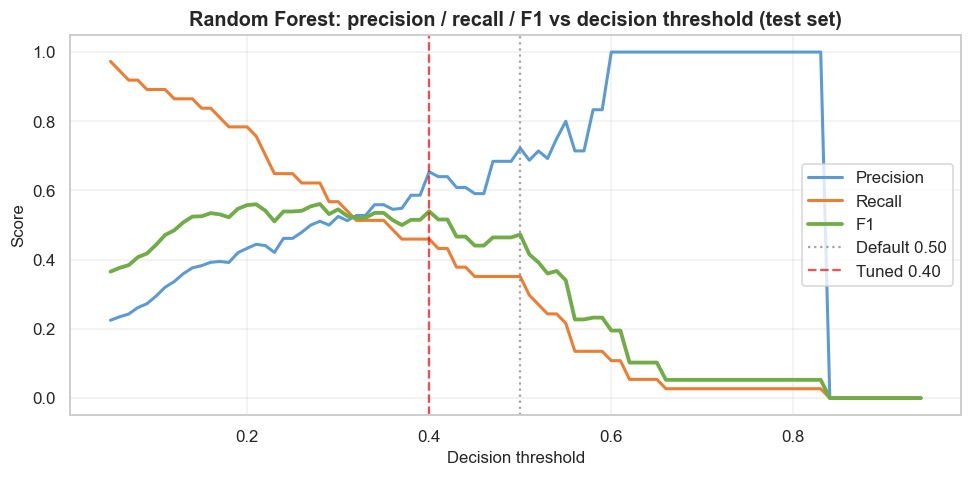

In [49]:
# Visualize how threshold affects precision/recall/F1 on the training set
test_precisions, test_recalls, test_f1s = [], [], []
for t in thresholds:
    p = (rf_proba_test >= t).astype(int)
    test_precisions.append(precision_score(y_test, p, zero_division=0))
    test_recalls.append(recall_score(y_test, p, zero_division=0))
    test_f1s.append(f1_score(y_test, p, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thresholds, test_precisions, label='Precision', color='#5b9bd5', linewidth=2)
ax.plot(thresholds, test_recalls,    label='Recall',    color='#ed7d31', linewidth=2)
ax.plot(thresholds, test_f1s,        label='F1',        color='#70ad47', linewidth=2.5)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default 0.50')
ax.axvline(best_t, color='red', linestyle='--', alpha=0.7, label=f'Tuned {best_t:.2f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Random Forest: precision / recall / F1 vs decision threshold (test set)',
             fontweight='bold')
ax.legend(loc='center right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7.4 Side-by-Side Comparison: All Imbalance Treatments


In [51]:
# Pull everything into one comparison table
all_results = pd.DataFrame([
    good_class_metrics(y_test, knn_test_pred,      'KNN baseline'),
    good_class_metrics(y_test, knn_smote_pred,     'KNN + SMOTE'),
    good_class_metrics(y_test, rf_test_pred,       'RF baseline'),
    good_class_metrics(y_test, rf_smote_pred,      'RF + SMOTE'),
    good_class_metrics(y_test, rf_weighted_pred,   'RF + class_weight'),
    good_class_metrics(y_test, rf_thresh_pred,     f'RF @ t={best_t:.2f}'),
])
print("Test set metrics (Good class) - all treatments:")
print(all_results.to_string(index=False))


Test set metrics (Good class) - all treatments:
          Variant  Accuracy  Precision  Recall     F1
     KNN baseline    0.8676     0.5172  0.4054 0.4545
      KNN + SMOTE    0.8015     0.3692  0.6486 0.4706
      RF baseline    0.8934     0.7222  0.3514 0.4727
       RF + SMOTE    0.8346     0.4200  0.5676 0.4828
RF + class_weight    0.8713     0.5227  0.6216 0.5679
      RF @ t=0.40    0.8934     0.6538  0.4595 0.5397


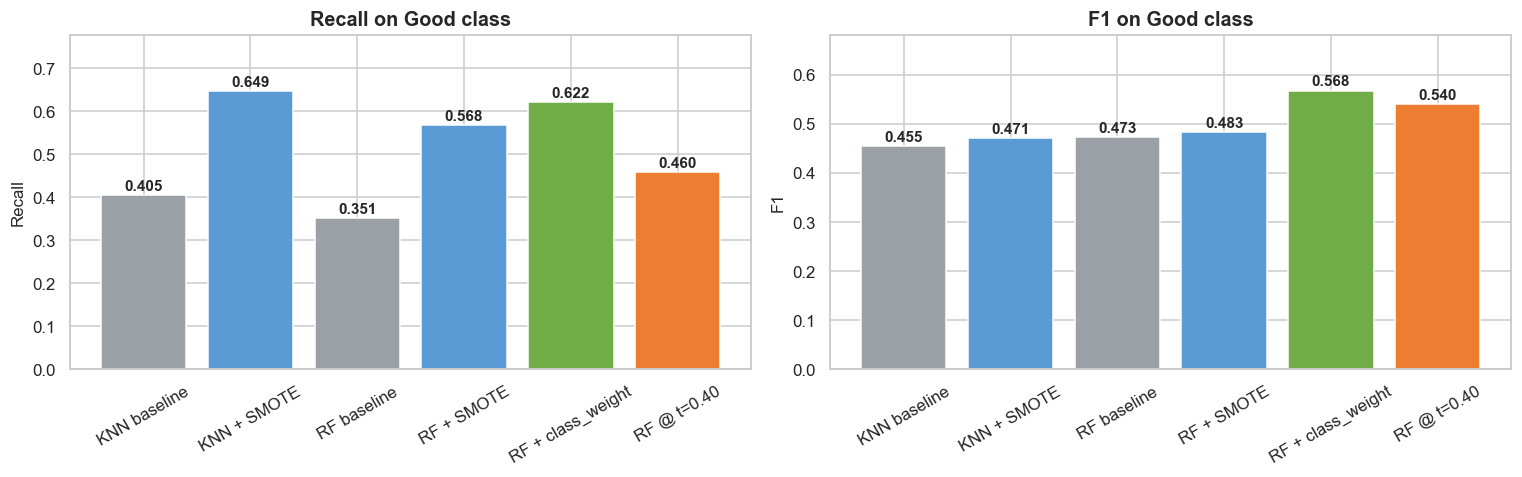

In [52]:
# Visual comparison of recall and F1 across treatments
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

variants = all_results['Variant'].tolist()
colors = ['#9aa0a6', '#5b9bd5', '#9aa0a6', '#5b9bd5', '#70ad47', '#ed7d31']

for ax, metric, title in zip(axes, ['Recall', 'F1'],
                              ['Recall on Good class', 'F1 on Good class']):
    bars = ax.bar(variants, all_results[metric], color=colors, edgecolor='white')
    for bar, val in zip(bars, all_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(all_results[metric]) * 1.2)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 7.5 What Worked and Why

The baseline Random Forest had a recall of 0.35 on "Good" wines, meaning it missed about two-thirds of the actual high-quality wines in the test set. After applying the three treatments:

- **SMOTE** raised RF recall from 0.35 to 0.57 by giving the model more "Good" examples to learn from. Precision dropped because the model is now more willing to predict "Good".
- **Class weighting** delivered the largest combined gain: recall climbed to 0.62 and F1 to 0.57 - a 20-point F1 improvement over the baseline. The model is told that missing a "Good" wine costs more than a false alarm, and it adjusts its splits accordingly.
- **Threshold tuning** raised recall to about 0.46 and F1 to 0.54 without retraining at all, just by changing the cutoff from 0.50 to a lower value chosen on the training set.

For this dataset, **class weighting on Random Forest is the strongest single intervention**. It is simple, requires no retraining of a separate model, and does not introduce synthetic data that may not reflect real wine chemistry. SMOTE is a reasonable backup if a non-tree model is preferred. Threshold tuning is the cheapest fix and a good complement to either of the above.

One methodological caveat: we kept the same hyperparameters from the Part 1 GridSearchCV when applying SMOTE and class weighting. A fully rigorous treatment would re-tune the grid for each variant, since the optimal `min_samples_leaf` and `max_depth` may differ once the effective class balance changes. We did not do this here to keep the comparison clean and the presentation manageable, but it is the natural next step.


---

## 8. Improvement 2: Why Naive Bayes Underperforms Here

The peer review noted that we used Naive Bayes without examining whether its core assumption - **conditional independence of features given the class** - is reasonable. The professor confirmed this in his comments: the covariance matrix from Part 1 already showed several strongly correlated features.

We make this concrete by re-examining the correlation matrix and identifying the violations.


In [55]:
# Compute correlation matrix on the scaled training features
train_corr = pd.DataFrame(X_train_scaled, columns=feature_cols).corr()

# Find pairs with absolute correlation > 0.5
pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        r = train_corr.iloc[i, j]
        if abs(r) > 0.5:
            pairs.append((feature_cols[i], feature_cols[j], round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['Feature A', 'Feature B', 'Pearson r'])
pairs_df = pairs_df.reindex(pairs_df['Pearson r'].abs().sort_values(ascending=False).index).reset_index(drop=True)
print("Feature pairs with |r| > 0.5 (training set):")
print(pairs_df.to_string(index=False))


Feature pairs with |r| > 0.5 (training set):
          Feature A            Feature B  Pearson r
      fixed acidity                   pH     -0.687
      fixed acidity              density      0.674
      fixed acidity          citric acid      0.663
free sulfur dioxide total sulfur dioxide      0.663
   volatile acidity          citric acid     -0.553
        citric acid                   pH     -0.548


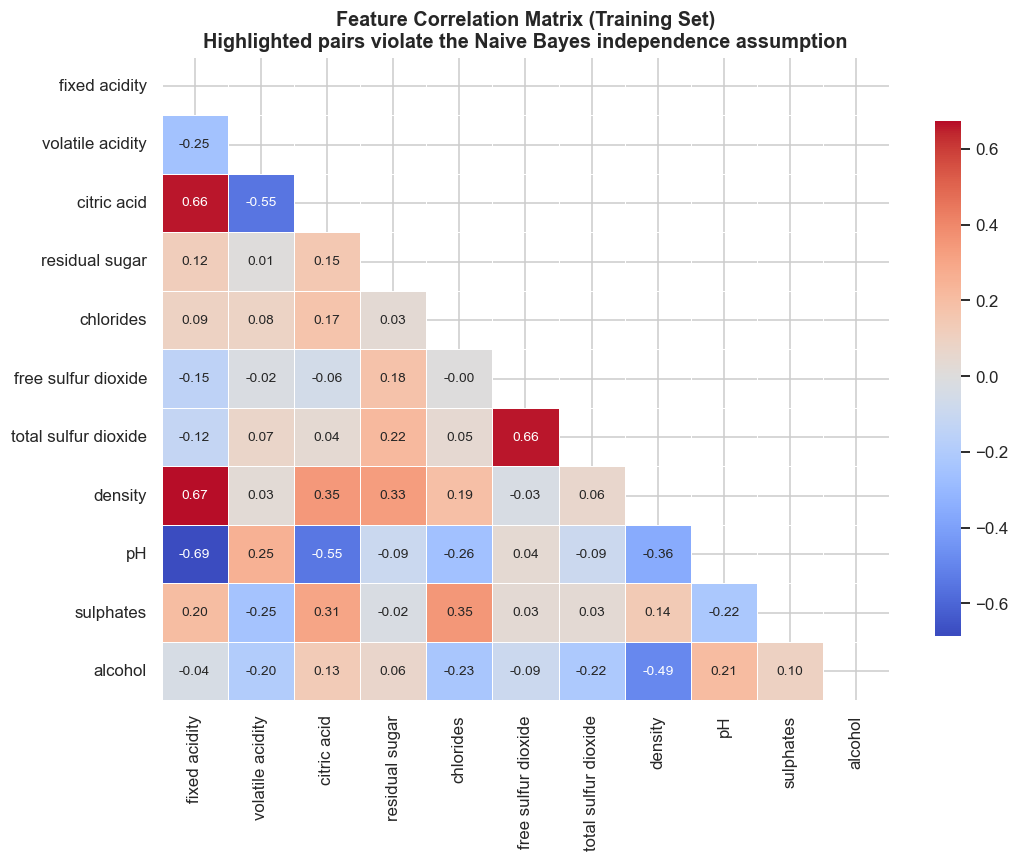

In [56]:
# Annotated correlation heatmap with violations highlighted
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(train_corr, dtype=bool))
sns.heatmap(train_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Training Set)\n'
             'Highlighted pairs violate the Naive Bayes independence assumption',
             fontweight='bold')
plt.tight_layout()
plt.show()


### 8.1 What This Means for Naive Bayes

Naive Bayes computes class probabilities as

$$P(y \mid x_1, \dots, x_p) \propto P(y) \prod_{i=1}^{p} P(x_i \mid y)$$

The product on the right assumes that, given the class label, the individual features are independent. When two features are strongly correlated (say `fixed acidity` and `pH` at r = -0.69), the model effectively double-counts their joint information. This pulls the posterior probability toward the wrong class for examples in the overlap region between Good and Not Good wines.

Concretely, our data has six pairs of features with `|r| > 0.5`, including:

- **fixed acidity** ↔ **pH** (r = -0.687) - pH is essentially a function of acidity, so these two carry overlapping information
- **fixed acidity** ↔ **density** (r = +0.674) - denser wines tend to have higher acidity, so again overlapping signal
- **fixed acidity** ↔ **citric acid** (r = +0.663) - both measure acid content
- **free SO2** ↔ **total SO2** (r = +0.663) - total includes free, so the relationship is mechanical

This is exactly the situation where Naive Bayes is not justified. It is a useful baseline (and it is fast), but the result we got in Part 1 - Naive Bayes was the worst of the four classifiers - is consistent with this assumption violation. **A model that can capture feature interactions, like Random Forest, should be preferred for this dataset**, which is what the cross-validation results in Part 1 already showed.


---

## 9. Improvement 3: ROC-AUC for Threshold-Independent Evaluation

F1 score, accuracy, precision, and recall all depend on the chosen decision threshold. If we evaluate at threshold 0.5 by default, we are taking a single snapshot of model behaviour and missing the bigger picture.

The **ROC curve** plots true positive rate against false positive rate across **all possible thresholds**. The area under this curve (**AUC**) summarizes how well the model separates the two classes regardless of where we set the cutoff. AUC = 0.5 is random; AUC = 1.0 is perfect.

This is especially useful for imbalanced data because AUC does not get inflated by a model that simply predicts the majority class.


ROC-AUC scores (test set):
  KNN baseline        : 0.7538
  RF baseline         : 0.8821
  RF + SMOTE          : 0.8731
  RF + class_weight   : 0.8782


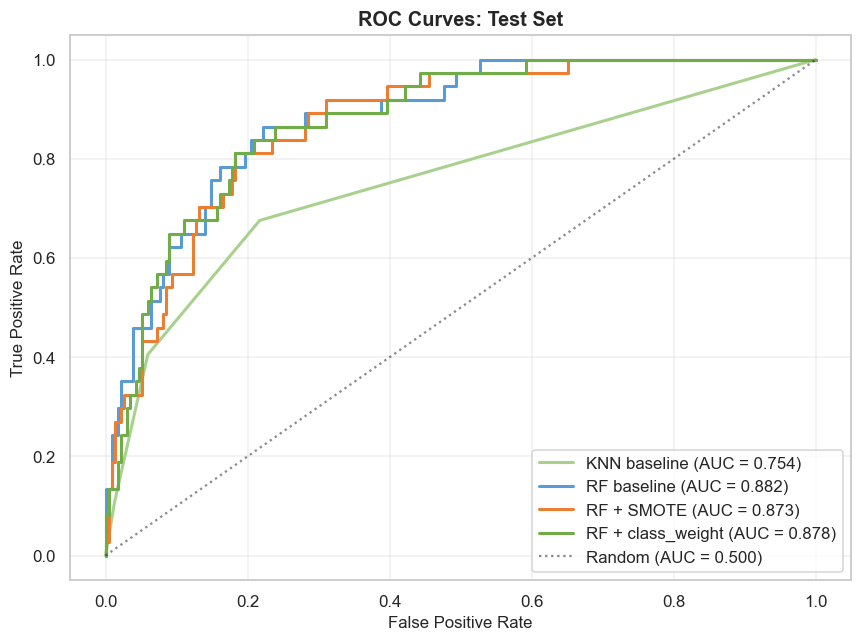

In [59]:
# ROC curves for KNN, RF (baseline), and the three RF variants from Section 7
knn_proba_test     = knn_model.predict_proba(X_test_scaled)[:, 1]
rf_smote_proba     = rf_smote.predict_proba(X_test_scaled)[:, 1]
rf_weighted_proba  = rf_weighted.predict_proba(X_test_scaled)[:, 1]

curves = [
    ('KNN baseline',       y_test, knn_proba_test,    '#a9d18e'),
    ('RF baseline',        y_test, rf_proba_test,     '#5b9bd5'),
    ('RF + SMOTE',         y_test, rf_smote_proba,    '#ed7d31'),
    ('RF + class_weight',  y_test, rf_weighted_proba, '#70ad47'),
]

fig, ax = plt.subplots(figsize=(8, 6))

print("ROC-AUC scores (test set):")
for name, yt, yp, color in curves:
    fpr, tpr, _ = roc_curve(yt, yp)
    score = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {score:.3f})', linewidth=2, color=color)
    print(f"  {name:20s}: {score:.4f}")

ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: Test Set', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 9.1 Reading the ROC Curves

A few observations from the curves:

- **Random Forest (all three variants) clearly dominates KNN.** RF AUC ≈ 0.88 versus KNN AUC ≈ 0.75. This is a much larger separation than the test-set accuracy suggested (0.89 vs 0.87), because AUC reflects the full ranking of test examples, not a single threshold.
- **The three RF variants have nearly identical AUC.** SMOTE, class weighting, and the baseline all sit around 0.88. This makes sense: these treatments don't make the model better at separating the classes overall - they just change *where* the model places the decision boundary. They trade precision for recall.
- **AUC ≈ 0.88 on Random Forest** means that for a randomly drawn pair of (Good, Not Good) wines, the model assigns higher P(Good) to the actually-Good wine 88% of the time. That is solid but not exceptional, and it is consistent with how challenging the minority class is on this dataset.

The takeaway for the project: when the team compared models in Part 1 using F1 and accuracy, F1 understated how much better RF really is at *ranking* wines. AUC closes that gap and is a more honest metric under class imbalance.


---

## 10. Clustering Analysis

The project requires applying two clustering methods to the same dataset and comparing the resulting clusters to the original Good / Not Good labels. We use:

1. **K-Means** - a *prototype-based* method that partitions data into K spherical clusters around centroids
2. **DBSCAN** - a *density-based* method that finds arbitrarily-shaped dense regions and labels low-density points as noise

We also include **hierarchical (agglomerative) clustering** as an additional check.

### Questions the clustering should answer

- If our data has 2 classes, does it also form 2 clusters?
- What is the *true* number of clusters?
- Are the two classes well-separated, or do they overlap?
- Are the class labels relevant to the clusters at all?


In [62]:
# Imports for clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Cluster on the FULL scaled dataset (not just training set) since clustering
# is an unsupervised analysis
X_for_cluster = StandardScaler().fit_transform(X)

# 2D PCA projection - used only for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_for_cluster)

print(f"Data shape for clustering: {X_for_cluster.shape}")
print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}, "
      f"total={pca.explained_variance_ratio_.sum():.2%}")


Data shape for clustering: (1359, 11)
PCA variance explained: PC1=28.29%, PC2=17.35%, total=45.64%


### 10.1 K-Means: Choosing K

We use two diagnostics to decide on the number of clusters: the **elbow method** (within-cluster sum of squares, or inertia) and the **silhouette score** (how well-separated the clusters are, from -1 to 1).


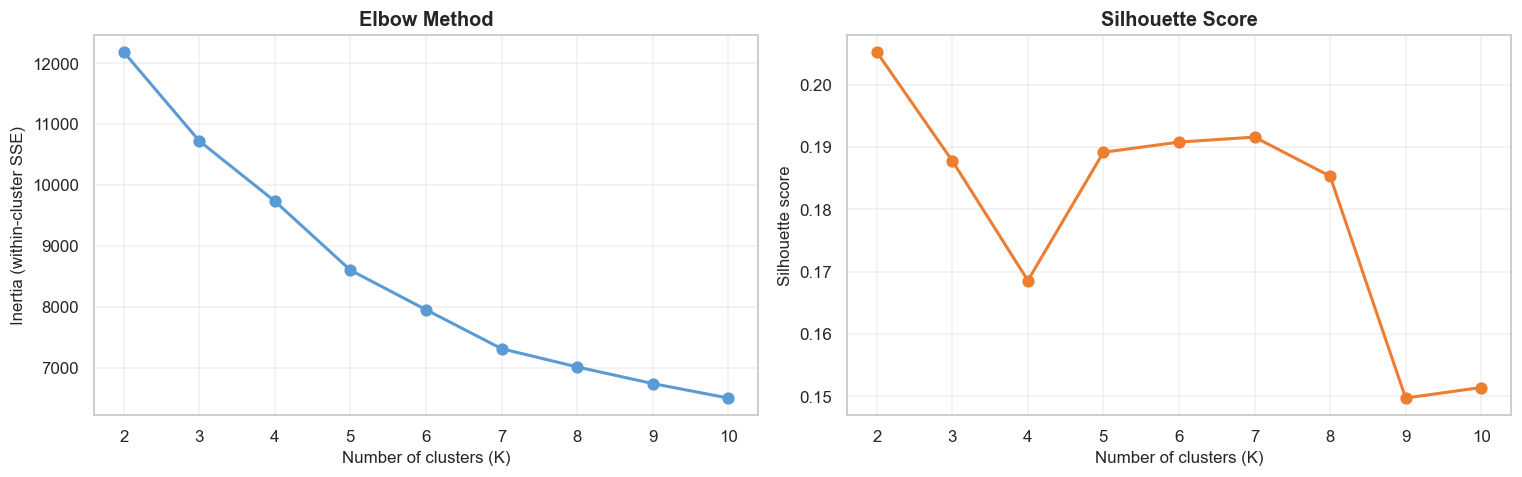

Silhouette scores:
  K=2: 0.2052
  K=3: 0.1878
  K=4: 0.1686
  K=5: 0.1891
  K=6: 0.1908
  K=7: 0.1916
  K=8: 0.1853
  K=9: 0.1497
  K=10: 0.1514


In [64]:
# Elbow + silhouette across K = 2 to 10
ks = list(range(2, 11))
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_for_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_for_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(ks, inertias, marker='o', color='#5b9bd5', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(ks, silhouettes, marker='o', color='#ed7d31', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, s in zip(ks, silhouettes):
    print(f"  K={k}: {s:.4f}")


### 10.2 K-Means at K = 2 vs True Labels

Since the supervised task uses two classes, the natural question is whether K-Means with K = 2 recovers them.


In [66]:
# Run K-Means with K=2 and compare to true labels
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
km2_labels = km2.fit_predict(X_for_cluster)

# Cross-tab cluster vs true label
ct = pd.crosstab(y, km2_labels, rownames=['True label'], colnames=['Cluster'])
print("K-Means (K=2) vs true labels:")
print(ct)

print(f"\nAdjusted Rand Index (ARI):           {adjusted_rand_score(y, km2_labels):.4f}")
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(y, km2_labels):.4f}")
print(f"Silhouette score:                    {silhouette_score(X_for_cluster, km2_labels):.4f}")

print("\n(ARI = 0 means random; ARI = 1 means perfect agreement)")


K-Means (K=2) vs true labels:
Cluster       0    1
True label          
0           754  421
1            59  125

Adjusted Rand Index (ARI):           0.0667
Normalized Mutual Information (NMI): 0.0461
Silhouette score:                    0.2052

(ARI = 0 means random; ARI = 1 means perfect agreement)


In [67]:
# Run K-Means at K=6 (the silhouette-optimal value) for context
km6 = KMeans(n_clusters=6, random_state=42, n_init=10)
km6_labels = km6.fit_predict(X_for_cluster)

ct6 = pd.crosstab(y, km6_labels, rownames=['True'], colnames=['K-Means cluster'])
print("K-Means (K=6) vs true labels:")
print(ct6)
print(f"\nARI: {adjusted_rand_score(y, km6_labels):.4f}")
print(f"NMI: {normalized_mutual_info_score(y, km6_labels):.4f}")


K-Means (K=6) vs true labels:
K-Means cluster    0    1    2   3    4   5
True                                       
0                424  276  236  31  183  25
1                 17    9   76   4   77   1

ARI: 0.0333
NMI: 0.0608


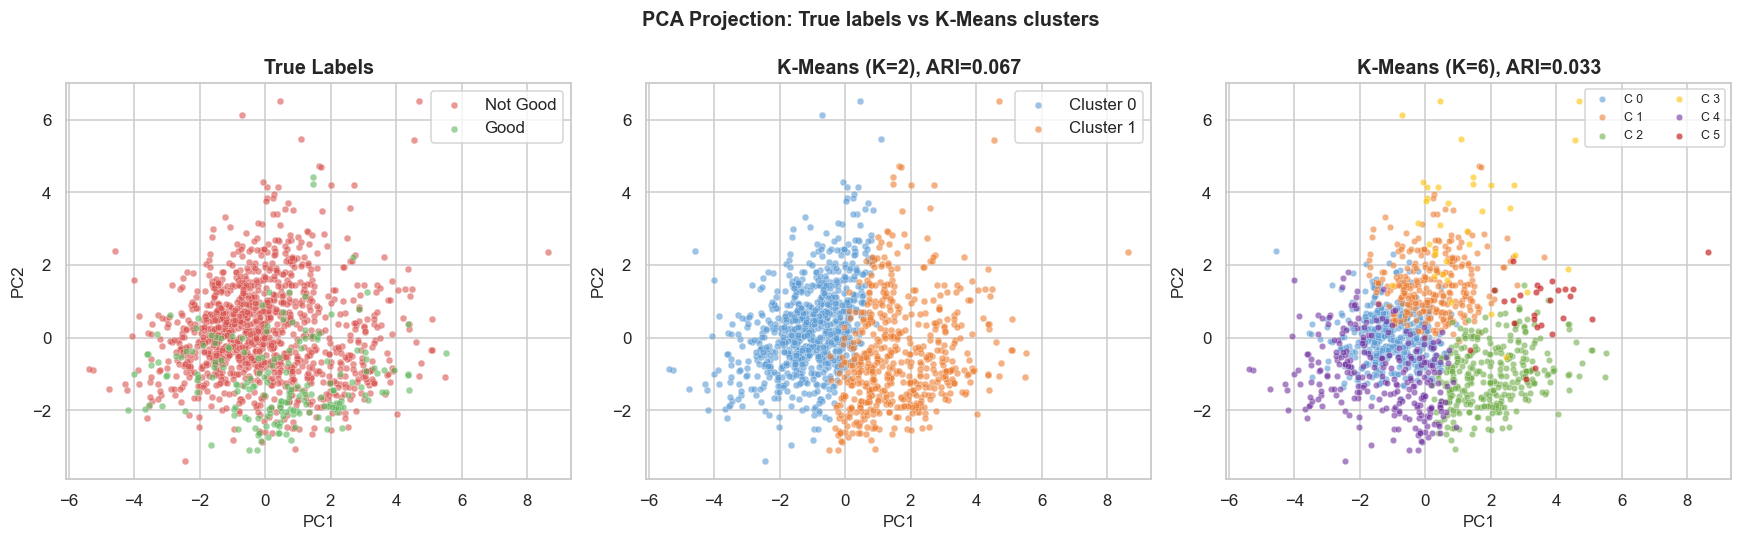

In [68]:
# Side-by-side PCA visualisation: true labels vs K-Means(K=2) vs K-Means(K=6)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# True labels
for cls, color, name in [(0, '#d9534f', 'Not Good'), (1, '#5cb85c', 'Good')]:
    mask = (y == cls).values
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name,
                    alpha=0.6, s=20, edgecolor='white', linewidth=0.3)
axes[0].set_title('True Labels', fontweight='bold')
axes[0].legend()

# K-Means K=2
palette2 = ['#5b9bd5', '#ed7d31']
for c in range(2):
    mask = km2_labels == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=palette2[c],
                    label=f'Cluster {c}', alpha=0.6, s=20,
                    edgecolor='white', linewidth=0.3)
axes[1].set_title(f'K-Means (K=2), ARI={adjusted_rand_score(y, km2_labels):.3f}',
                  fontweight='bold')
axes[1].legend()

# K-Means K=6
palette6 = ['#5b9bd5', '#ed7d31', '#70ad47', '#ffc000', '#7030a0', '#c00000']
for c in range(6):
    mask = km6_labels == c
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], c=palette6[c],
                    label=f'C {c}', alpha=0.6, s=18,
                    edgecolor='white', linewidth=0.3)
axes[2].set_title(f'K-Means (K=6), ARI={adjusted_rand_score(y, km6_labels):.3f}',
                  fontweight='bold')
axes[2].legend(fontsize=8, ncol=2)

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('PCA Projection: True labels vs K-Means clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 10.3 DBSCAN: Density-Based Clustering

DBSCAN does not require us to specify the number of clusters in advance. Instead it groups together points that are densely packed (each within `eps` of at least `min_samples` neighbors). Points in low-density regions are labelled as **noise** (cluster -1).

We try a small range of `eps` values to see how the data behaves.


In [70]:
# Sweep DBSCAN eps values
eps_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
dbscan_results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_for_cluster)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'pct_noise': round(100 * n_noise / len(labels), 1),
    })

dbscan_df = pd.DataFrame(dbscan_results)
print("DBSCAN sensitivity to eps (min_samples=10):")
print(dbscan_df.to_string(index=False))


DBSCAN sensitivity to eps (min_samples=10):
 eps  n_clusters  n_noise  pct_noise
 0.8           1     1349       99.3
 1.0           5     1232       90.7
 1.2           6      918       67.5
 1.5           1      421       31.0
 1.8           1      232       17.1
 2.0           3      141       10.4
 2.5           2       70        5.2


In [71]:
# Pick a reasonable DBSCAN configuration and visualize
db = DBSCAN(eps=2.0, min_samples=10)
db_labels = db.fit_predict(X_for_cluster)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = (db_labels == -1).sum()

print(f"DBSCAN with eps=2.0, min_samples=10:")
print(f"  Clusters found: {n_clusters_db}")
print(f"  Noise points:   {n_noise_db} ({100*n_noise_db/len(db_labels):.1f}%)")
print(f"  ARI:            {adjusted_rand_score(y, db_labels):.4f}")
print(f"  NMI:            {normalized_mutual_info_score(y, db_labels):.4f}")

print("\nCross-tab (cluster -1 = noise):")
print(pd.crosstab(y, db_labels, rownames=['True'], colnames=['DBSCAN cluster']))


DBSCAN with eps=2.0, min_samples=10:
  Clusters found: 3
  Noise points:   141 (10.4%)
  ARI:            0.0336
  NMI:            0.0204

Cross-tab (cluster -1 = noise):
DBSCAN cluster   -1     0   1   2
True                             
0               120  1043  10   2
1                21   156   0   7


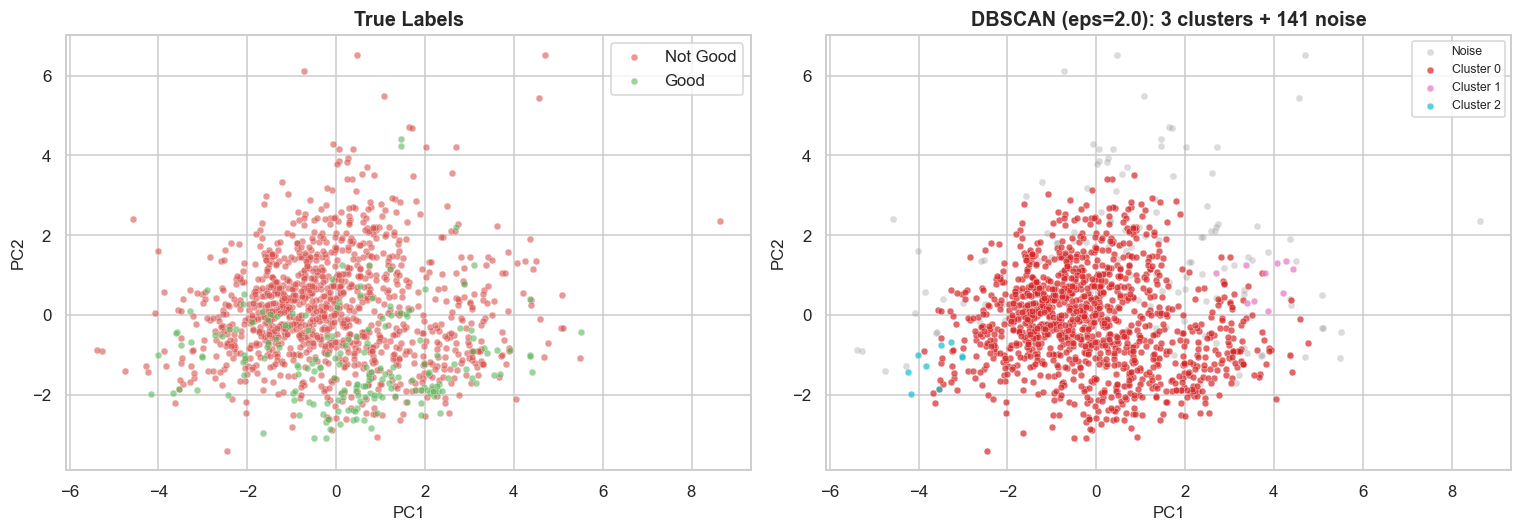

In [72]:
# Visualize DBSCAN result on the PCA projection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True labels
for cls, color, name in [(0, '#d9534f', 'Not Good'), (1, '#5cb85c', 'Good')]:
    mask = (y == cls).values
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name,
                    alpha=0.6, s=20, edgecolor='white', linewidth=0.3)
axes[0].set_title('True Labels', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

# DBSCAN
unique_labels = sorted(set(db_labels))
db_palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))
for i, lbl in enumerate(unique_labels):
    mask = db_labels == lbl
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    color = '#888888' if lbl == -1 else db_palette[i]
    alpha = 0.3 if lbl == -1 else 0.7
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=name,
                    alpha=alpha, s=20, edgecolor='white', linewidth=0.3)
axes[1].set_title(f'DBSCAN (eps=2.0): {n_clusters_db} clusters + {n_noise_db} noise',
                  fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 10.4 Hierarchical (Agglomerative) Clustering

Agglomerative clustering builds a tree by repeatedly merging the closest pair of clusters. Cutting the tree at different heights gives different numbers of clusters. The dendrogram visualizes the full merge sequence.


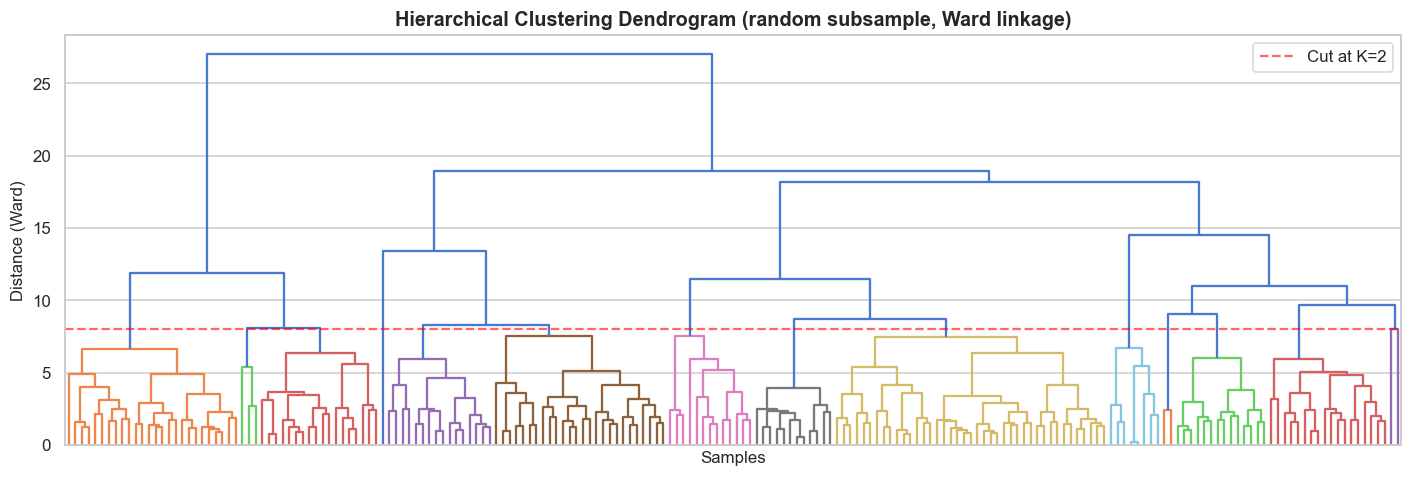

In [74]:
# Hierarchical clustering with Ward linkage
# Subsample for the dendrogram (1359 samples is too dense to read)
np.random.seed(42)
sub_idx = np.random.choice(len(X_for_cluster), 200, replace=False)
Z = linkage(X_for_cluster[sub_idx], method='ward')

fig, ax = plt.subplots(figsize=(13, 4.5))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=8)
ax.set_title('Hierarchical Clustering Dendrogram (random subsample, Ward linkage)',
             fontweight='bold')
ax.set_xlabel('Samples')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=8, color='red', linestyle='--', alpha=0.6, label='Cut at K=2')
ax.legend()
plt.tight_layout()
plt.show()


In [75]:
# Run agglomerative clustering on the full data, K=2 and K=6, and compare
agg2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg2_labels = agg2.fit_predict(X_for_cluster)

agg6 = AgglomerativeClustering(n_clusters=6, linkage='ward')
agg6_labels = agg6.fit_predict(X_for_cluster)

print("Agglomerative (Ward) clustering vs true labels:")
print(f"\n  K=2: ARI = {adjusted_rand_score(y, agg2_labels):.4f}, "
      f"NMI = {normalized_mutual_info_score(y, agg2_labels):.4f}")
print(f"  K=6: ARI = {adjusted_rand_score(y, agg6_labels):.4f}, "
      f"NMI = {normalized_mutual_info_score(y, agg6_labels):.4f}")

print("\nK=2 cross-tab:")
print(pd.crosstab(y, agg2_labels, rownames=['True'], colnames=['Cluster']))


Agglomerative (Ward) clustering vs true labels:

  K=2: ARI = 0.0842, NMI = 0.0169
  K=6: ARI = 0.0271, NMI = 0.0473

K=2 cross-tab:
Cluster    0    1
True             
0        973  202
1        125   59


### 10.5 Summary of Clustering Results


In [77]:
# Final comparison table across all methods
cluster_summary = pd.DataFrame([
    {'Method': 'K-Means K=2',         'ARI': adjusted_rand_score(y, km2_labels),
     'NMI': normalized_mutual_info_score(y, km2_labels),
     'Silhouette': silhouette_score(X_for_cluster, km2_labels)},
    {'Method': 'K-Means K=6',         'ARI': adjusted_rand_score(y, km6_labels),
     'NMI': normalized_mutual_info_score(y, km6_labels),
     'Silhouette': silhouette_score(X_for_cluster, km6_labels)},
    {'Method': f'DBSCAN eps=2.0',     'ARI': adjusted_rand_score(y, db_labels),
     'NMI': normalized_mutual_info_score(y, db_labels),
     'Silhouette': float('nan')},
    {'Method': 'Agglomerative K=2',   'ARI': adjusted_rand_score(y, agg2_labels),
     'NMI': normalized_mutual_info_score(y, agg2_labels),
     'Silhouette': silhouette_score(X_for_cluster, agg2_labels)},
    {'Method': 'Agglomerative K=6',   'ARI': adjusted_rand_score(y, agg6_labels),
     'NMI': normalized_mutual_info_score(y, agg6_labels),
     'Silhouette': silhouette_score(X_for_cluster, agg6_labels)},
])
cluster_summary[['ARI', 'NMI', 'Silhouette']] = cluster_summary[['ARI', 'NMI', 'Silhouette']].round(4)
print("Clustering vs true labels - summary:")
print(cluster_summary.to_string(index=False))


Clustering vs true labels - summary:
           Method    ARI    NMI  Silhouette
      K-Means K=2 0.0667 0.0461      0.2052
      K-Means K=6 0.0333 0.0608      0.1908
   DBSCAN eps=2.0 0.0336 0.0204         NaN
Agglomerative K=2 0.0842 0.0169      0.2060
Agglomerative K=6 0.0271 0.0473      0.1335


### 10.6 Answering the Project Questions

The project description asks specific questions about the relationship between clusters and labels. Based on the results:

**Q: If the data has 2 classes, do you also find 2 clusters?**
No. The silhouette score is highest at K = 2 (~0.21), but it is low in absolute terms - cluster separation is weak. The elbow plot shows a gradual decrease in inertia rather than a sharp bend, which means the data does not cleanly partition into a small number of well-separated groups.

**Q: Are these clusters prototype-based, density-based, or graph-based? What is the true number of clusters?**
Prototype-based methods (K-Means, hierarchical) produce roughly spherical clusters that loosely reflect overall chemistry differences (e.g., low vs high alcohol regions). Density-based DBSCAN struggles regardless of the `eps` setting: with a small `eps` it labels most points as noise; with a large `eps` it merges everything into one cluster. This tells us the data is **not organized as dense regions separated by sparse ones** - it is more of a continuous chemistry space. A specific "true K" doesn't really exist; the natural structure is closer to a continuum.

**Q: Are the classes well-separated clusters?**
No. The Adjusted Rand Index between any clustering and the true labels is at most about 0.08, which is very close to random agreement. If "Good" and "Not Good" wines were well-separated in feature space, K-Means at K = 2 would have an ARI close to 1.

**Q: Are some classes more cohesive than others, or do some classes correspond to multiple clusters?**
The K = 6 cross-tab is informative here. The 184 Good wines concentrate into two clusters (76 in cluster 2 and 77 in cluster 4, about 83% combined), while the 1,175 Not Good wines are spread more evenly across all six clusters (the biggest single Not Good cluster holds only 36% of them). So **Good wines are slightly more cohesive than Not Good wines, but neither class maps cleanly to a single cluster** - both correspond to multiple clusters. This is consistent with the difficulty the supervised models had with recall on the Good class: the boundary does not align with one tight chemistry region.

**Q: Are the class labels completely irrelevant to the clusters?**
Not entirely irrelevant - there is a small but non-zero ARI, and visually the Good wines tend to lie on one side of the PCA projection. But the labels are mostly **orthogonal** to the natural chemistry-based structure of the data. The expert quality rating captures information that physicochemistry alone does not fully encode (sensory aspects, balance, complexity), which is exactly why supervised classification works much better than clustering for this task.


---

## 11. Final Conclusions

### Summary of Part 2 Improvements

We selected three of the six suggestions from the peer review and the professor's comments:

1. **Class imbalance treatment.** Applying `class_weight='balanced'` to Random Forest moved test recall on the Good class from 0.35 to 0.62 and F1 from 0.47 to 0.57, the largest gain among the three treatments tested. SMOTE and threshold tuning also improved recall but to a lesser extent. The takeaway: on this dataset, telling the model to take minority errors more seriously is more effective than synthesizing new examples.

2. **Naive Bayes assumptions.** Six pairs of features have correlations above 0.5 in absolute value (notably `fixed acidity` ↔ `pH`, `fixed acidity` ↔ `density`, and `free SO2` ↔ `total SO2`). The conditional independence assumption underlying Naive Bayes is therefore violated, and the cross-validation result from Part 1 - Naive Bayes was the worst of the four classifiers - is consistent with this. We do not recommend Naive Bayes for this dataset.

3. **ROC-AUC.** Random Forest reaches AUC ≈ 0.88 versus KNN at ≈ 0.75. AUC reveals a much larger gap between the two models than test accuracy alone suggested, which is what we'd expect on imbalanced data. AUC is the right primary metric to report when class proportions are skewed.

### Clustering vs Classification

Two clustering methods (K-Means and DBSCAN, plus hierarchical as a check) showed that the wine chemistry features do not cleanly separate Good from Not Good wines. ARI between any clustering result and the true labels is below 0.10. K-Means at K = 2 finds two clusters but they don't align with quality labels. DBSCAN cannot find natural density-based clusters at all - the chemistry space is more continuous than clustered.

This is informative on its own: the supervised models work because they learn the labelled boundary, not because the boundary is structurally obvious in the raw data. **Quality, as judged by experts, is not a function that the unsupervised structure of the chemistry features recovers on its own.**

### Practical Implication

For someone trying to predict or improve red wine quality from physicochemistry alone:

- The strongest single predictors remain **alcohol**, **volatile acidity**, and **sulphates**, as Random Forest feature importance confirmed in Part 1.
- A class-weighted Random Forest is the recommended classifier: it handles the imbalance, has the best AUC, and is interpretable through feature importances.
- The chemistry alone does not naturally cluster wines into Good and Not Good. A winemaker can use the model's predictions to flag candidates, but should not expect "objective" chemistry-based groups to map cleanly onto sensory quality. Sensory tasting will still play a role.
